In [151]:
import os
import dill
import numpy as np
import oqupy
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
from scipy.interpolate import interp1d
from oqupy import operators as op
import matplotlib.pyplot as plt

pt_dict={}
folder='results/processtensors_lowercoupling'

# System setup


Rho_0=oqupy.operators.spin_dm('x+')

num_params=1
tcut=30
epsrel=10**(-8)
def hamiltonian_t(t):
    return oqupy.operators.sigma("x")/2*0

def hamiltonian_param(hx):
    return hx*oqupy.operators.sigma("x")/2

 53.2%  426 of  800 [#####################-------------------] 00:01:05--> Compute forward propagation:
100.0%  800 of  800 [########################################] 00:00:07
Elapsed time: 7.7s
--> Compute backward propagation:
100.0%  800 of  800 [########################################] 00:00:07
Elapsed time: 7.1s
--> Apply chain rule:
100.0%  800 of  800 [########################################] 00:00:37
Elapsed time: 37.4s
--> Compute forward propagation:
100.0%  800 of  800 [########################################] 00:00:05
Elapsed time: 5.8s
--> Compute backward propagation:
100.0%  800 of  800 [########################################] 00:00:06
Elapsed time: 6.7s
--> Apply chain rule:
100.0%  800 of  800 [########################################] 00:00:38
Elapsed time: 38.5s


Text(0.5, 0, '$ t$ [ps]')

 53.2%  426 of  800 [#####################-------------------] 00:02:49

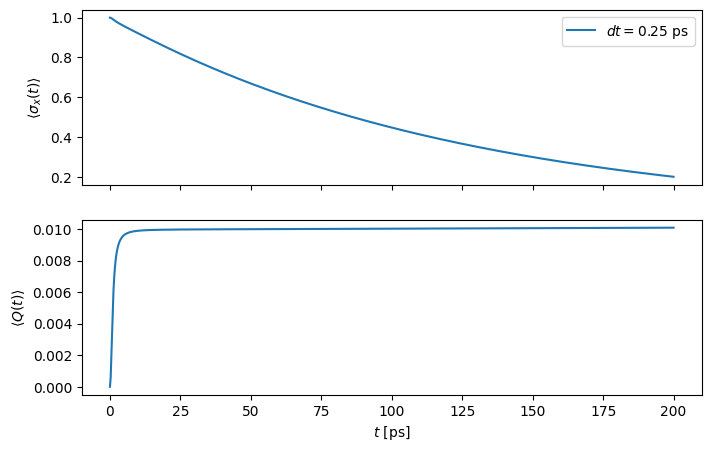

 53.2%  426 of  800 [#####################-------------------] 00:04:15

In [ ]:

t_prot=200
fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
epsrel=10**(-8)
tcut=30
dt=0.25
folder='results/processtensors'
file_name1=os.path.join(folder,'processtensor_dt={0}_ps={1}_tcut={2}'.format(dt,np.round(np.log10(epsrel),1),tcut))
with open(file_name1,'rb') as f:
    pt=dill.load(f)

file_name1=os.path.join(folder,'processtensorCF_dt={0}_ps={1}_tcut={2}'.format(dt,np.round(np.log10(epsrel),1),tcut))
with open(file_name1,'rb') as f:
    ptcf=dill.load(f)
#system = oqupy.TimeDependentSystem(hamiltonian_t)
system=oqupy.ParameterizedSystem(hamiltonian_param)


num_steps = int(np.round(t_prot / dt))
hx=np.zeros(2*num_steps)
hx=np.vstack(hx)
'''
dynamics = oqupy.compute_dynamics(
    process_tensor=pt,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

dynamicscf = oqupy.compute_dynamics(
    process_tensor=ptcf,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)
'''
grad=oqupy.state_gradient(
    process_tensors=[pt],
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps,
    parameters=hx,
    target_derivative=op.spin_dm('mixed').T
)

gradcf=oqupy.state_gradient(
process_tensors=[ptcf],
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps,
parameters=hx,
target_derivative=-1j*np.identity(2)/0.01
)

dynamics=grad['dynamics']
dynamicscf=gradcf['dynamics']


t,final_x = dynamics.expectations(op.sigma('x'), real=True)
final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / 0.01
axs[0].plot(t,final_x,'-',label=r'$dt={0}$ ps'.format(dt))
axs[1].plot(t,final_Q,'-')

axs[0].legend()
axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
axs[1].set_xlabel(r'$ t$ [ps]')


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


 46.2%  132 of  286 [##################----------------------] 07:58:06

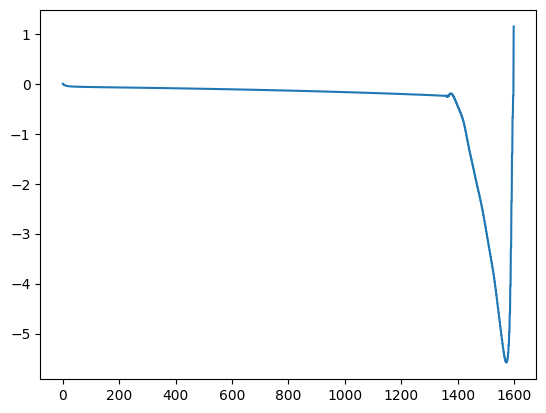

 50.0%  400 of  800 [####################--------------------] 00:24:18

In [164]:
plt.plot(gradcf['gradient'])

  9.2%   37 of  400 [###-------------------------------------] 03:01:33

<Axes: >

 65.0%   93 of  143 [##########################--------------] 00:17:47

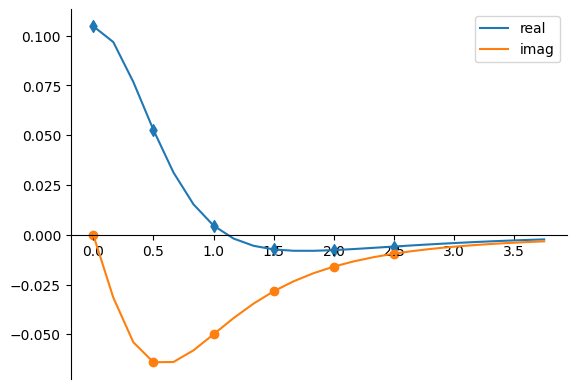

In [28]:
correlations = oqupy.PowerLawSD(alpha=0.05,
                                zeta=1,
                                cutoff=1,
                                cutoff_type='exponential',
                                temperature=0.131)
sigma_z = oqupy.operators.sigma("z")
bath = oqupy.Bath(0.5 * sigma_z, correlations)

fig, ax = plt.subplots()
params = oqupy.TempoParameters(dt=0.5, epsrel=1, tcut=2.5) # N.B. epsrel not used by helper, and tcut only to set plot t-limits
oqupy.helpers.plot_correlations_with_parameters(bath.correlations, params, ax=ax)

--> Compute dynamics:
100.0%  714 of  714 [########################################] 00:00:30
Elapsed time: 30.9s
--> Compute dynamics:
100.0%  714 of  714 [########################################] 00:00:31
Elapsed time: 31.6s
--> Compute dynamics:
100.0%  714 of  714 [########################################] 00:00:26
Elapsed time: 26.6s
--> Compute dynamics:
100.0%  714 of  714 [########################################] 00:00:26
Elapsed time: 26.4s
--> Compute dynamics:
100.0%  714 of  714 [########################################] 00:00:25
Elapsed time: 25.3s
--> Compute dynamics:
100.0%  714 of  714 [########################################] 00:00:28
Elapsed time: 28.8s
--> Compute dynamics:
100.0%  714 of  714 [########################################] 00:00:25
Elapsed time: 25.2s
--> Compute dynamics:
100.0%  714 of  714 [########################################] 00:00:24
Elapsed time: 24.9s
--> Compute dynamics:
100.0%  714 of  714 [########################################] 00:

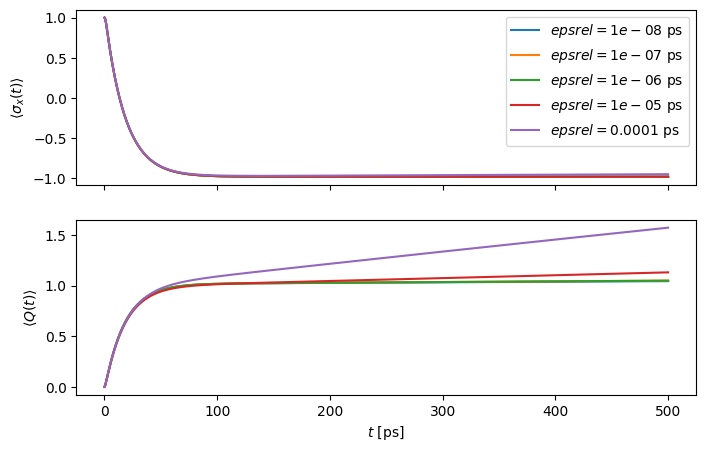

In [29]:
dt=0.7
tcut=30

fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
for epsrel in [10**(-8),10**(-7),10**(-6),10**(-5),10**(-4)]:
    file_name1=os.path.join(folder,'processtensor_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
    with open(file_name1,'rb') as f:
        pt=dill.load(f)

    file_name1=os.path.join(folder,'processtensorCF_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
    with open(file_name1,'rb') as f:
        ptcf=dill.load(f)
    system = oqupy.TimeDependentSystem(hamiltonian_t)

    num_steps = int(np.round(t_prot / dt))

    dynamics = oqupy.compute_dynamics(
        process_tensor=pt,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)

    dynamicscf = oqupy.compute_dynamics(
        process_tensor=ptcf,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)
    
    final_x = dynamics.expectations(op.sigma('x'), real=True)[1]
    final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / 0.01
    axs[0].plot(np.linspace(0,t_prot,len(final_x)),final_x,'-',label=r'$epsrel={0}$ ps'.format(epsrel))
    axs[1].plot(np.linspace(0,t_prot,len(final_x)),final_Q,'-')

    axs[0].legend()
    axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
    axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
    axs[1].set_xlabel(r'$ t$ [ps]')

plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'results/processtensors/processtensorCF_dt=0.7_ps=-6.0_tcut=5_alpha=0.05'

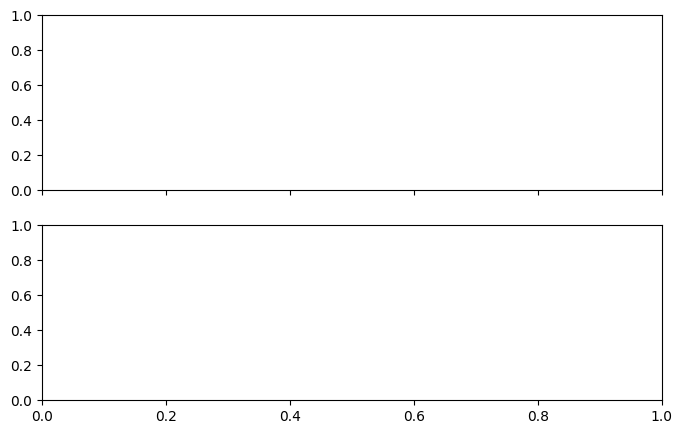

In [ ]:
dt=0.7
epsrel=10**(-6)
fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
for tcut in [5,10,20,30]:
    file_name1=os.path.join(folder,'processtensor_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
    with open(file_name1,'rb') as f:
        pt=dill.load(f)


    file_name1=os.path.join(folder,'processtensorCF_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
    with open(file_name1,'rb') as f:
        ptcf=dill.load(f)
    system = oqupy.TimeDependentSystem(hamiltonian_t)

    num_steps = int(np.round(t_prot / dt))

    dynamics = oqupy.compute_dynamics(
        process_tensor=pt,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)

    dynamicscf = oqupy.compute_dynamics(
        process_tensor=ptcf,
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=num_steps)
    
    final_x = dynamics.expectations(op.sigma('x'), real=True)[1]
    final_Q = dynamicscf.states.trace(axis1=1, axis2=2).imag / 0.01
    axs[0].plot(np.linspace(0,t_prot,len(final_x)),final_x,'-',label=r'$tcut={0}$ ps'.format(tcut))
    axs[1].plot(np.linspace(0,t_prot,len(final_x)),final_Q,'-')

    axs[0].legend()
    axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
    axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
    axs[1].set_xlabel(r'$ t$ [ps]')

plt.show()

In [58]:
tcut=20
epsrel=10**(-6)
dt=0.7

file_name1='results/zero_control_lowercoupling/500ps/optimization_simplemodel_500ps'
with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)

opt_dict['opttime'][0]/60

29.978314832846323

 46.2%  132 of  286 [##################----------------------] 00:34:37

--> Compute dynamics:
100.0%  286 of  286 [########################################] 00:00:11
Elapsed time: 11.6s
--> Compute dynamics:
100.0%  286 of  286 [########################################] 00:00:09
Elapsed time: 9.3s
--> Compute dynamics:
100.0%  286 of  286 [########################################] 00:00:14
Elapsed time: 14.5s
--> Compute dynamics:
100.0%  286 of  286 [########################################] 00:00:19
Elapsed time: 19.9s


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_83258/4128498049.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


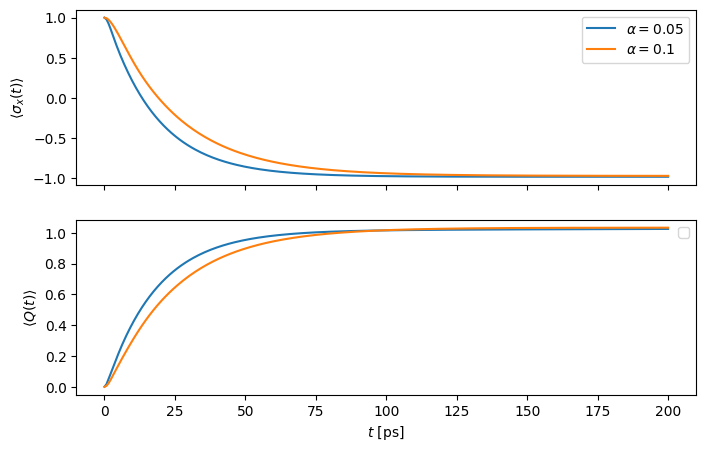

In [129]:
dt=0.7
epsrel=10**(-6)
tcut=20
fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
t_prot=200
folder='results/processtensors_lowercoupling'
file_name1=os.path.join(folder,'processtensor_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
with open(file_name1,'rb') as f:
    pt_05=dill.load(f)

file_name1=os.path.join(folder,'processtensorCF_dt={0}_ps={1}_tcut={2}_alpha=0.05'.format(dt,np.round(np.log10(epsrel),1),tcut))
with open(file_name1,'rb') as f:
    ptcf_05=dill.load(f)

folder='results/processtensors'
# larger coupling, dt=0.25 , tcut=30 , epsrel=7
file_name1=os.path.join(folder,'processtensor_dt={0}_ps={1}_tcut={2}'.format(0.25,np.round(np.log10(10**(-7)),1),30))
with open(file_name1,'rb') as f:
    pt_1=dill.load(f)

file_name1=os.path.join(folder,'processtensorCF_dt={0}_ps={1}_tcut={2}'.format(0.25,np.round(np.log10(10**(-7)),1),30))
with open(file_name1,'rb') as f:
    ptcf_1=dill.load(f)

system = oqupy.TimeDependentSystem(hamiltonian_t)

num_steps = int(np.round(t_prot / dt))

dynamics_05 = oqupy.compute_dynamics(
    process_tensor=pt_05,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

dynamicscf_05 = oqupy.compute_dynamics(
    process_tensor=ptcf_05,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

dynamics_1 = oqupy.compute_dynamics(
    process_tensor=pt_1,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

dynamicscf_1 = oqupy.compute_dynamics(
    process_tensor=ptcf_1,
    system=system,
    initial_state=Rho_0,
    start_time=0,
    num_steps=num_steps)

final_x = dynamics_05.expectations(op.sigma('x'), real=True)[1]
final_Q = dynamicscf_05.states.trace(axis1=1, axis2=2).imag / 0.01
axs[0].plot(np.linspace(0,t_prot,len(final_x)),final_x,'-',label=r'$\alpha=0.05$')
axs[1].plot(np.linspace(0,t_prot,len(final_x)),final_Q,'-')

final_x = dynamics_1.expectations(op.sigma('x'), real=True)[1]
final_Q = dynamicscf_1.states.trace(axis1=1, axis2=2).imag / 0.01
axs[0].plot(np.linspace(0,t_prot,len(final_x)),final_x,'-',label=r'$\alpha=0.1$')
axs[1].plot(np.linspace(0,t_prot,len(final_x)),final_Q,'-')

axs[0].legend()
axs[0].set_ylabel(r'$\langle \sigma_x (t) \rangle$')
axs[1].set_ylabel(r'$\langle Q (t) \rangle$')
axs[1].set_xlabel(r'$ t$ [ps]')
plt.legend()
plt.show()
folder='results/processtensors_lowercoupling'

In [130]:
import os 
# dt=0.7 eps=10**(-6) tcut=20ps
file_name1='results/zero_control_lowercoupling/500ps/optimization_simplemodel_500ps'
with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)

file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-6.0_tcut=20/500ps'
with open(file_name1,'rb') as f:
    opt_dict01=dill.load(f)

file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-8.0_tcut=30/500ps'
with open(file_name1,'rb') as f:
    opt_dict02=dill.load(f)

file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-9.0_tcut=30/500ps'
with open(file_name1,'rb') as f:
    opt_dict03=dill.load(f)

file_name1='results/zero_control_lowercoupling/500ps/optimization_simplemodel_500ps'
with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)

# dt=0.5 eps=10**(-7)  tcut=30
file_name1='results/opt_convergence_lowercoupling/dt=0.5ps_eps=-7.0_tcut=30/500ps'
with open(file_name1,'rb') as f:
    opt_dict2=dill.load(f)

file_name1='results/opt_convergence_lowercoupling/dt=0.5ps_eps=-8.0_tcut=30/500ps'
with open(file_name1,'rb') as f:
    opt_dict3=dill.load(f)

 46.2%  132 of  286 [##################----------------------] 00:36:01

In [128]:
# varying epsrel

t1,sx1=opt_dict['fidelitygrad']['dynamics'].expectations(op.sigma('x'), real=True)

plt.plot(t1[:-1],opt_dict['result'].x)
plt.show()

t2,sx2=opt_dict2['dynamics'].expectations(op.sigma('x'),real=True)
t3,sx3=opt_dict2['dynamics'].expectations(op.sigma('x'),real=True)
t01,sx01=opt_dict01['dynamics'].expectations(op.sigma('x'),real=True)
t02,sx02=opt_dict02['dynamics'].expectations(op.sigma('x'),real=True)
t03,sx03=opt_dict03['dynamics'].expectations(op.sigma('x'),real=True)
plt.plot(t1,sx1)
plt.plot(t2,sx2)
plt.plot(t2,sx3)
plt.plot(t01,sx01)
plt.plot(t02,sx02,label='eps=-8.0')
plt.plot(t03,sx03,label='eps=-8.0')
plt.legend()
plt.show()

plt.plot(t1,opt_dict['log'][-1]['full heats'])
plt.plot(t2,opt_dict2['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='2')
plt.plot(t2,opt_dict3['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='3')
plt.plot(t01,opt_dict01['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='epsrel=-6')
plt.plot(t02,opt_dict02['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='epsrel=-8')
plt.plot(t03,opt_dict03['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='sprel=-9')
print(len(t1))

plt.legend()
plt.show()



KeyError: 'fidelitygrad'

 46.2%  132 of  286 [##################----------------------] 00:34:36

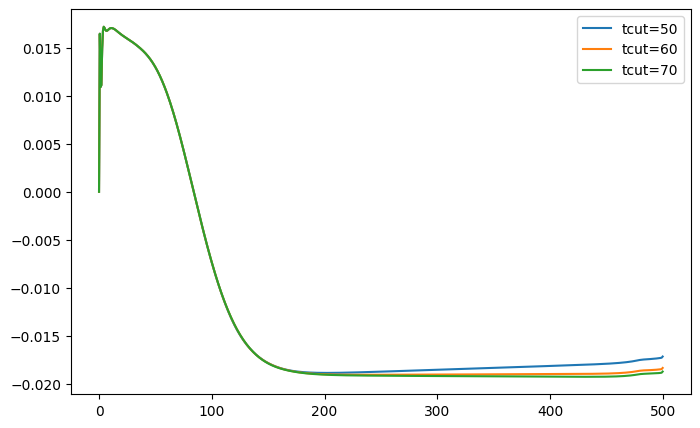

In [ ]:
# varytcut 
fig,axs = plt.subplots(1, figsize=(8, 5), sharex=True)
for tcut in [50,60,70]:
    file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-8.0_tcut={0}/500ps'.format(tcut)
    with open(file_name1,'rb') as f:
        opt_dict=dill.load(f)

    t,sx=opt_dict['dynamics'].expectations(op.sigma('x'),real=True)
    #axs[0].plot(t,sx,label='tcut={0}'.format(tcut))

    axs.plot(t,opt_dict['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='tcut={0}'.format(tcut))
    plt.legend()



715


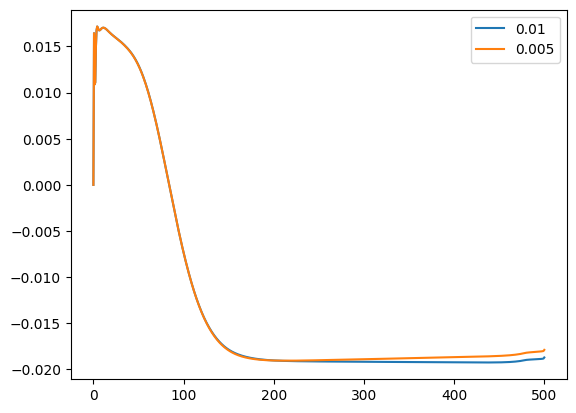

In [95]:
file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-8.0_tcut=70/500ps'.format(tcut)
with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)

file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-8.0_tcut=70_u=0.005/500ps'.format(tcut)
with open(file_name1,'rb') as f:
    opt_dict2=dill.load(f)

t,sx=opt_dict['dynamics'].expectations(op.sigma('x'),real=True)
print(len(t))
plt.plot(t,opt_dict['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label='0.01')
plt.plot(t,opt_dict2['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.005,label='0.005')
plt.legend()
plt.show()

 50.0%  400 of  800 [####################--------------------] 00:24:19

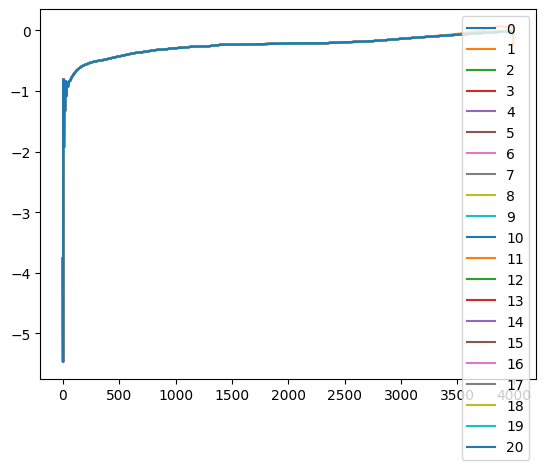

 53.2%  426 of  800 [#####################-------------------] 00:06:11

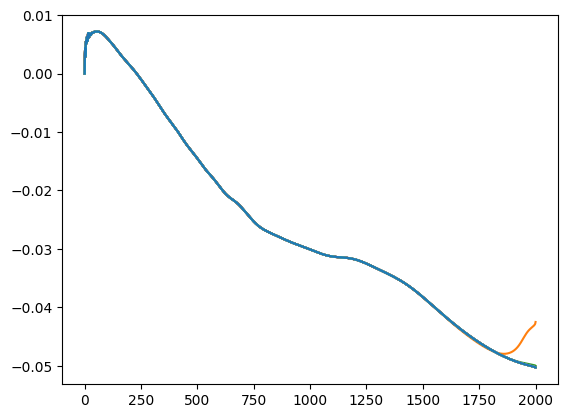

{'epsrel': 1e-08, 'alpha': 0.05, 'omega_cutoff': 1, 'temp': 0.131, 'dt': 0.25, 'tcut': 30}


 53.2%  426 of  800 [#####################-------------------] 03:27:31

In [ ]:
file_name1='results/zero_control_lowercoupling/dt=0.25_ps=-8.0_tcut=30_alpha=0.05/500ps'
#file_name1='results/zero_control_lowercoupling/500ps/optimization_simplemodel_500ps'
with open(file_name1,'rb') as f:
    opt_dict=dill.load(f)

for i in range(len(opt_dict['log'])):
    plt.plot(opt_dict['log'][i]['x'],label='{0}'.format(i))
plt.legend()
plt.show()
for i in range(len(opt_dict['log'])):
    plt.plot(opt_dict['log'][i]['full heats'],label='{0}'.format(i))
plt.show()

print(opt_dict['parameters'])


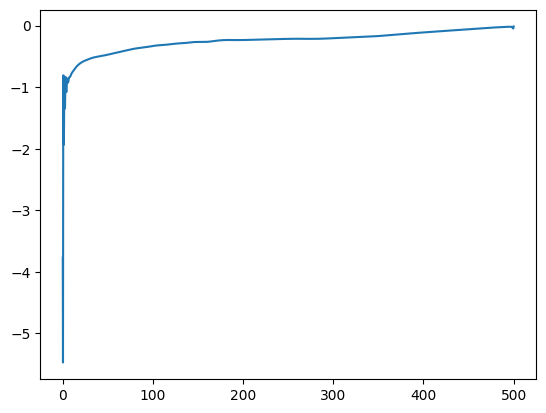

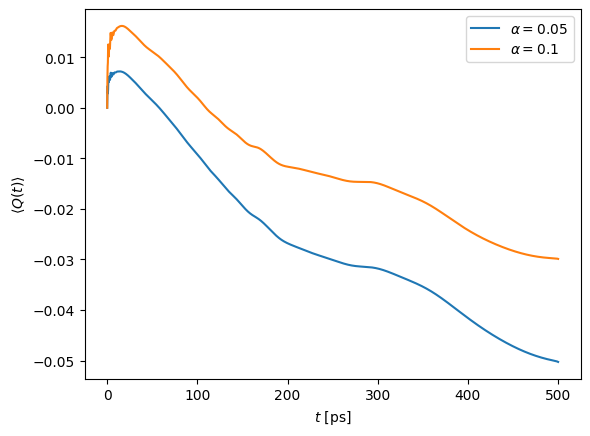

ValueError: x and y must have same first dimension, but have shapes (2001,) and (715,)

 46.2%  132 of  286 [##################----------------------] 06:06:43

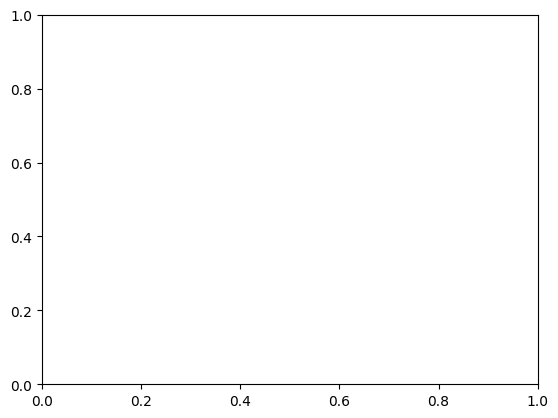

 46.2%  132 of  286 [##################----------------------] 07:20:44

In [ ]:
file_name1='results/optimised_longer/dt=0.25ps_eps=-8.0_tcut=50/500ps'.format(tcut)
with open(file_name1,'rb') as f:
    opt_dict_1=dill.load(f)

file_name1='results/zero_control_lowercoupling/dt=0.25_ps=-8.0_tcut=30_alpha=0.05/500ps'
with open(file_name1,'rb') as f:
        control_dict=dill.load(f)
control=control_dict['result'].x

plt.plot(np.linspace(0,500,len(control)),control)
plt.show()
heat=control_dict['log'][-1]['full heats']

t,sx=opt_dict['fidelitygrad']['dynamics'].expectations(op.sigma('x'), real=True)

t_1,sx_1=opt_dict_1['dynamics'].expectations(op.sigma('x'),real=True)

plt.plot(t_1,heat,label=r'$\alpha=0.05$')
plt.plot(t_1,opt_dict_1['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label=r'$\alpha=0.1$')
plt.xlabel(r'$t$ [ps]')
plt.ylabel(r'$\langle Q (t) \rangle$')
plt.legend()
plt.show()

plt.plot(t_1,sx,label=r'$\alpha=0.05$')

plt.plot(t_1,sx_1,label=r'$\alpha=0.1$')

plt.xlabel(r'$t$ [ps]')
plt.ylabel(r'$\langle \sigma_x \rangle$')
plt.legend()
plt.show()

 46.2%  132 of  286 [##################----------------------] 01:01:18

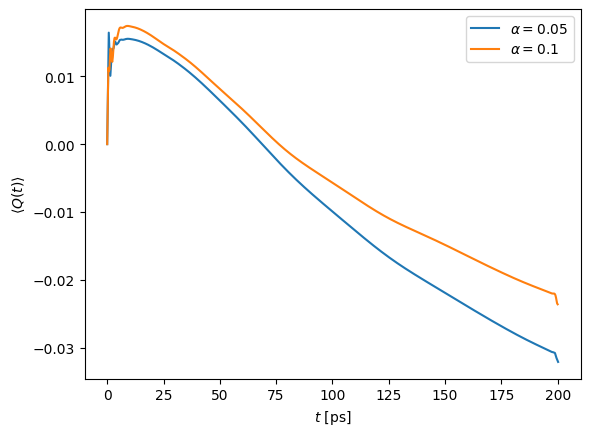

 27.3%   78 of  286 [##########------------------------------] 00:49:54

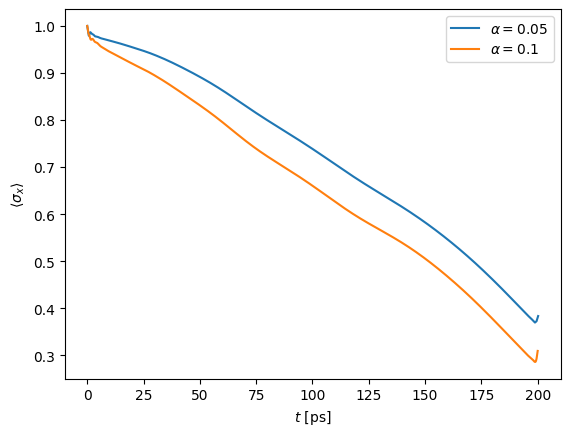

 27.3%   78 of  286 [##########------------------------------] 00:54:57

In [ ]:
file_name1='results/opt_convergence_lowercoupling/dt=0.7ps_eps=-8.0_tcut=60/200ps'.format(tcut)
with open(file_name1,'rb') as f:
    opt_dict_05=dill.load(f)

file_name1='results/optimised_longer/dt=0.25ps_eps=-8.0_tcut=50/200ps'.format(tcut)
with open(file_name1,'rb') as f:
    opt_dict_1=dill.load(f)
t_05,sx_05=opt_dict_05['dynamics'].expectations(op.sigma('x'),real=True)
t_05,sy_05=opt_dict_05['dynamics'].expectations(op.sigma('y'),real=True)
t_05,sz_05=opt_dict_05['dynamics'].expectations(op.sigma('z'),real=True)
t_1,sx_1=opt_dict_1['dynamics'].expectations(op.sigma('x'),real=True)
t_1,sy_1=opt_dict_1['dynamics'].expectations(op.sigma('y'),real=True)
t_1,sz_1=opt_dict_1['dynamics'].expectations(op.sigma('z'),real=True)

plt.plot(t_05,opt_dict_05['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label=r'$\alpha=0.05$')
plt.plot(t_1,opt_dict_1['dynamicscf'].states.trace(axis1=1,axis2=2).imag/0.01,label=r'$\alpha=0.1$')
plt.xlabel(r'$t$ [ps]')
plt.ylabel(r'$\langle Q (t) \rangle$')
plt.legend()
plt.show()

plt.plot(t_05,sx_05,label=r'$\alpha=0.05$')
#plt.plot(t_05,sy_05,label=r'$\alpha=0.05$')
#plt.plot(t_05,sz_05,label=r'$\alpha=0.05$')
plt.plot(t_1,sx_1,label=r'$\alpha=0.1$')
#plt.plot(t_1,sy_1,label=r'$\alpha=0.1$')
#plt.plot(t_1,sz_1,label=r'$\alpha=0.1$')
plt.xlabel(r'$t$ [ps]')
plt.ylabel(r'$\langle \sigma_x \rangle$')
plt.legend()
plt.show()

 46.2%  132 of  286 [##################----------------------] 05:43:59

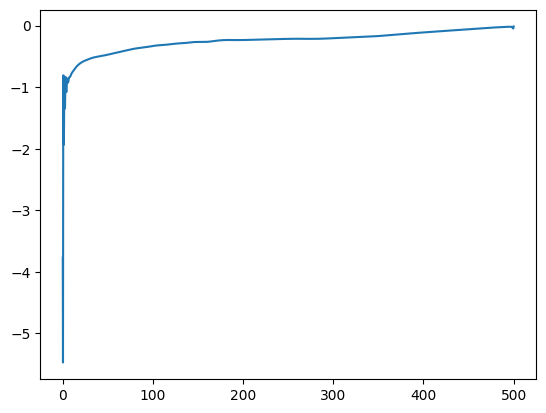

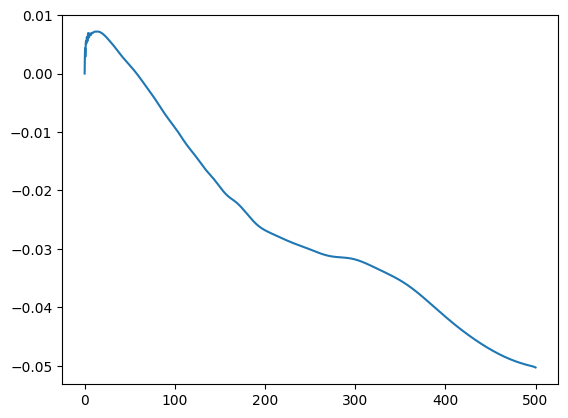

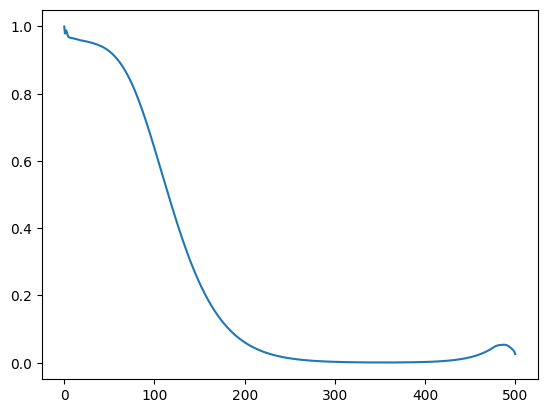

 27.3%   78 of  286 [##########------------------------------] 05:53:13

In [ ]:

file_name1='results/zero_control_lowercoupling/dt=0.25_ps=-8.0_tcut=30_alpha=0.05/500ps'
with open(file_name1,'rb') as f:
        control_dict=dill.load(f)
control=control_dict['result'].x

plt.plot(np.linspace(0,500,len(control)),control)
plt.show()
heat=control_dict['log'][-1]['full heats']
plt.plot(np.linspace(0,500,len(heat)),heat)
plt.show()
t,sx=opt_dict['fidelitygrad']['dynamics'].expectations(op.sigma('x'), real=True)
plt.plot(t,sx)
plt.show()

 50.0%  400 of  800 [####################--------------------] 03:46:31

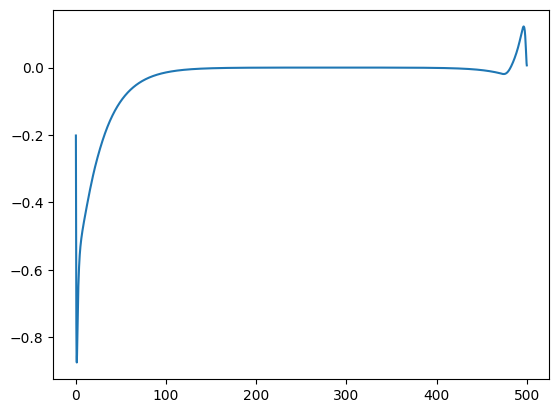

 53.2%  426 of  800 [#####################-------------------] 03:28:23

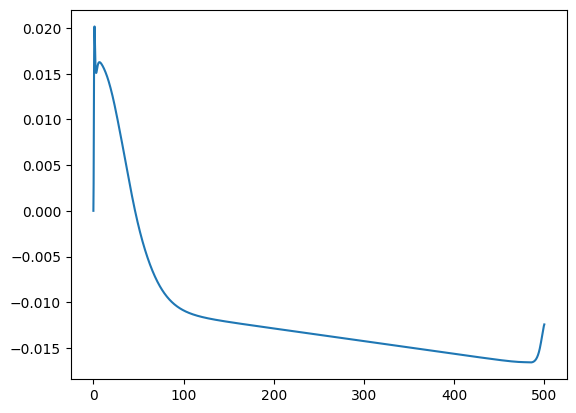

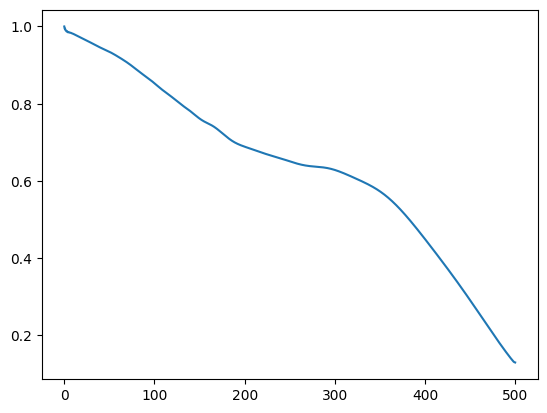

 27.3%   78 of  286 [##########------------------------------] 23:59:17:10:41

In [ ]:
file_name1='results/zero_control_lowercoupling/dt=0.25_ps=-8.0_tcut=30_alpha=0.05_new/500ps'

with open(file_name1,'rb') as f:
        control_dict=dill.load(f)
control=control_dict['result'].x

plt.plot(np.linspace(0,500,len(control)),control)
plt.show()
heat=control_dict['log'][-1]['full heats']
plt.plot(np.linspace(0,500,len(heat)),heat)
plt.show()
t,sx=opt_dict['fidelitygrad']['dynamics'].expectations(op.sigma('x'), real=True)
plt.plot(t,sx)
plt.show()
